In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu118 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 3.5 MB/s eta 0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 70.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 34.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 94.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 31.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 8.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00
Device : cuda
PyTorch: 2.3.1+cu118
Total available train samples: 56788
Train: 4000 | Val: 1000

  Model  : MedSAM
  Params : 23.48M
  Device : cuda
  Ep 001 | Loss:0.7332 | Dice:0.4980 | IoU:0.3365 | PixAcc:0.9619 | Acc:0.9619 | Prec:0.4158 | Rec:0.6313 | Spec:0.9722
  Ep 010 | Loss:0.4317 | Dice:0.6720 | IoU:0.5100 | PixAcc:0.9766 | Acc:0.9766 | Prec:0.5791 | Rec:0.8112 | Spec:0.9817
  Ep 020 | Loss:0.2484 | Dice:0.7115 | IoU:0.5563 | PixAcc:0.9815 | Acc:0.9815 | Prec:0.6651 | Rec:0.7732 | Spec:0.9880
  Ep 030 | Loss:0.1932 | Dice:0.7400 | IoU:0.5908 | PixAcc:0.9841 | Acc:0.9841 | Prec:0.7215 | Rec:0.7665 | Spec:0.9909
  Ep 040 | Loss:0.1763 | Dice:0.7518 | IoU:0.6059 | PixAcc:0.9850 | Acc:0.9850 | Prec:0.7382 | Rec:0.7720 | Spec:0.9916
  Ep 050 | Loss:0.1663 | Dice:0.7610 | IoU:0.6176 | PixAcc:0.9857 | Acc:0.9857 | Prec:0.7549 | Rec:0.7732 | Spec:0.9923
  Ep 060 | Loss:0.1603 | Dice:0.7641 | IoU:0.6216 |

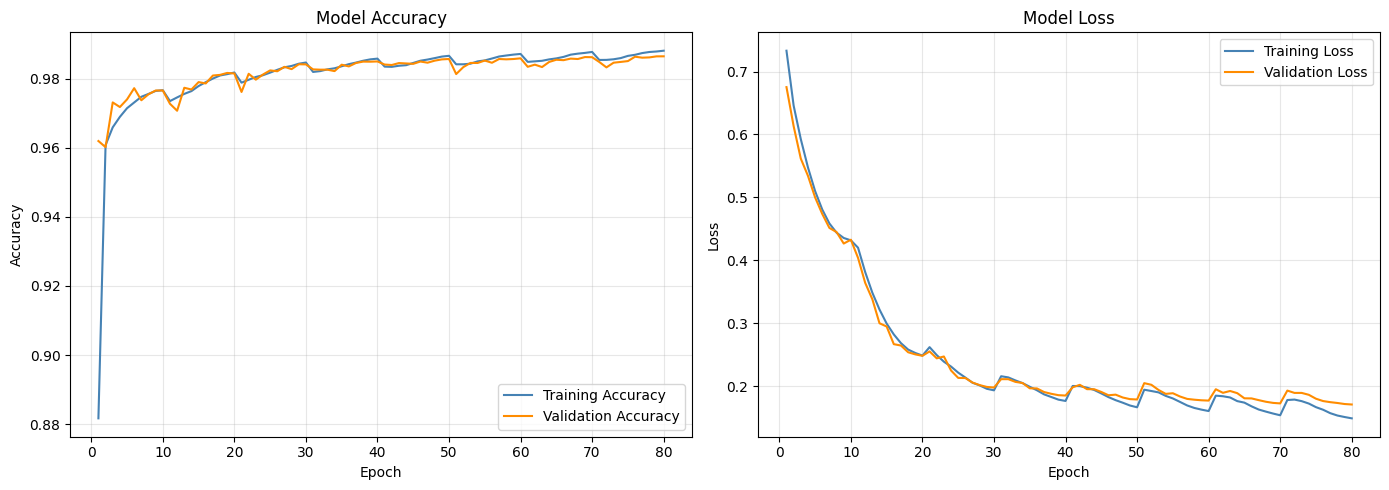

Plot saved to /kaggle/working/MedSAM_history.png

--- Evaluating on Train Set ---
Total available train samples: 56788
Train: 4000 | Val: 1000

  TRAIN EVALUATION
  Loss       : 0.1685
  Dice       : 77.55%
  IoU        : 63.72%
  Pixel Acc  : 98.66%
  Accuracy   : 98.66%
  Precision  : 76.68%
  Recall     : 78.88%
  Specificity: 99.27%

--- Evaluating on Validation Set ---
Total available train samples: 56788
Train: 4000 | Val: 1000

  VALIDATION EVALUATION
  Loss       : 0.1628
  Dice       : 78.36%
  IoU        : 64.80%
  Pixel Acc  : 98.70%
  Accuracy   : 98.70%
  Precision  : 77.87%
  Recall     : 79.21%
  Specificity: 99.30%

--- Evaluating on Test Set ---
Total available test samples: 10364
Using test samples: 1000

  TEST EVALUATION
  Loss       : 0.1678
  Dice       : 78.20%
  IoU        : 64.49%
  Pixel Acc  : 98.65%
  Accuracy   : 98.65%
  Precision  : 78.67%
  Recall     : 78.17%
  Specificity: 99.31%

[FINAL RESULT] MedSAM → Val Dice: 77.31% | Test IoU: 64.49%


In [2]:
import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch", "einops", "-q"], check=True)

import os, glob, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

BASE_PATH     = "/kaggle/input/datasets/ahmadnafeestihami/brats2021-2d-slices"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MSK_DIR = os.path.join(BASE_PATH, "train/masks")
TEST_IMG_DIR  = os.path.join(BASE_PATH, "test/images")
TEST_MSK_DIR  = os.path.join(BASE_PATH, "test/masks")

N_TRAIN = 4000
N_VAL   = 1000
N_TEST  = 1000

CFG = dict(
    img_size     = 256,
    batch_size   = 8,
    lr           = 1e-4,
    weight_decay = 1e-5,
    epochs       = 80,
    patience     = 10,
    device       = "cuda" if torch.cuda.is_available() else "cpu",
)
print(f"Device : {CFG['device']}")
print(f"PyTorch: {torch.__version__}")


class BraTSDataset(Dataset):
    def __init__(self, img_paths, mask_paths, img_size=256, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.img_size   = img_size
        self.augment    = augment

    def __len__(self):
        return len(self.img_paths)

    def _load(self, path, gray=False):
        img = Image.open(path).convert("L" if gray else "RGB")
        return img.resize((self.img_size, self.img_size), Image.BILINEAR)

    def __getitem__(self, idx):
        img  = self._load(self.img_paths[idx])
        mask = self._load(self.mask_paths[idx], gray=True)
        if self.augment:
            if random.random() > 0.5: img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() > 0.5: img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            if angle:
                img  = TF.rotate(img,  angle)
                mask = TF.rotate(mask, angle)
            img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
            img = TF.adjust_contrast(img,   random.uniform(0.8, 1.2))
        img  = TF.to_tensor(img)
        img  = TF.normalize(img, [0.5]*3, [0.5]*3)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask


def get_loaders():
    all_img_paths  = sorted(glob.glob(os.path.join(TRAIN_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TRAIN_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No images found at {TRAIN_IMG_DIR}"
    assert len(all_img_paths) == len(all_mask_paths), "Image/mask count mismatch!"
    print(f"Total available train samples: {len(all_img_paths)}")
    idx      = list(range(len(all_img_paths)))
    random.shuffle(idx)
    selected = idx[:N_TRAIN + N_VAL]
    t_idx    = selected[:N_TRAIN]
    v_idx    = selected[N_TRAIN:]
    train_ds = BraTSDataset([all_img_paths[i] for i in t_idx],
                             [all_mask_paths[i] for i in t_idx],
                             CFG["img_size"], augment=True)
    val_ds   = BraTSDataset([all_img_paths[i] for i in v_idx],
                             [all_mask_paths[i] for i in v_idx],
                             CFG["img_size"], augment=False)
    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
    return train_loader, val_loader


def get_test_loader():
    all_img_paths  = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TEST_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No test images found at {TEST_IMG_DIR}"
    print(f"Total available test samples: {len(all_img_paths)}")
    idx          = list(range(len(all_img_paths)))
    random.shuffle(idx)
    selected_idx = idx[:N_TEST]
    test_ds = BraTSDataset([all_img_paths[i] for i in selected_idx],
                            [all_mask_paths[i] for i in selected_idx],
                            CFG["img_size"], augment=False)
    print(f"Using test samples: {len(test_ds)}")
    return DataLoader(test_ds, batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=2, pin_memory=True)


class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2, 3))
        dice  = 1 - (2*inter + self.smooth) / (
                    prob.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return 0.5 * dice.mean() + 0.5 * bce


def compute_metrics(logits, masks, thresh=0.5):
    preds = (torch.sigmoid(logits) > thresh).float()
    inter = (preds * masks).sum()
    dice  = (2*inter + 1) / (preds.sum() + masks.sum() + 1)
    iou   = (inter + 1)   / (preds.sum() + masks.sum() - inter + 1)
    acc   = (preds == masks).float().mean()
    tp    = ((preds==1)&(masks==1)).sum().float()
    tn    = ((preds==0)&(masks==0)).sum().float()
    fp    = ((preds==1)&(masks==0)).sum().float()
    fn    = ((preds==0)&(masks==1)).sum().float()
    prec  = tp / (tp + fp + 1e-7)
    rec   = tp / (tp + fn + 1e-7)
    spec  = tn / (tn + fp + 1e-7)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    return dice.item(), iou.item(), acc.item(), prec.item(), rec.item(), spec.item(), pixel_acc.item()


def evaluate_split(model, loader, device, split_name):
    model.eval()
    criterion = DiceBCELoss()
    total_loss = 0.0
    v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            if out.shape[-2:] != masks.shape[-2:]:
                out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            total_loss += criterion(out, masks).item()
            d, i, a, p, r, s, px = compute_metrics(out, masks)
            v_dice += d; v_iou += i; v_acc += a
            v_prec += p; v_rec += r; v_spec += s; v_pix += px
    n = len(loader)
    print(f"\n{'='*60}")
    print(f"  {split_name} EVALUATION")
    print(f"{'='*60}")
    print(f"  Loss       : {total_loss/n:.4f}")
    print(f"  Dice       : {v_dice/n*100:.2f}%")
    print(f"  IoU        : {v_iou/n*100:.2f}%")
    print(f"  Pixel Acc  : {v_pix/n*100:.2f}%")
    print(f"  Accuracy   : {v_acc/n*100:.2f}%")
    print(f"  Precision  : {v_prec/n*100:.2f}%")
    print(f"  Recall     : {v_rec/n*100:.2f}%")
    print(f"  Specificity: {v_spec/n*100:.2f}%")
    print(f"{'='*60}")
    return v_dice/n, v_iou/n


def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history["train_acc"], color='steelblue',  linewidth=1.5, label="Training Accuracy")
    axes[0].plot(epochs, history["val_acc"],   color='darkorange', linewidth=1.5, label="Validation Accuracy")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["train_loss"], color='steelblue',  linewidth=1.5, label="Training Loss")
    axes[1].plot(epochs, history["val_loss"],   color='darkorange', linewidth=1.5, label="Validation Loss")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{model_name}_history.png", dpi=150)
    plt.show()
    print(f"Plot saved to /kaggle/working/{model_name}_history.png")


# ── MedSAM building blocks ────────────────────────────────────────────────────

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=3, embed_dim=768, patch_size=16):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)


class MLPBlock(nn.Module):
    def __init__(self, dim, mlp_dim):
        super().__init__()
        self.fc1  = nn.Linear(dim, mlp_dim)
        self.fc2  = nn.Linear(mlp_dim, dim)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        return self.fc2(self.drop(self.act(self.fc1(x))))


class WindowAttention(nn.Module):
    def __init__(self, dim, num_heads, window_size=14, dropout=0.0):
        super().__init__()
        self.num_heads   = num_heads
        self.window_size = window_size
        self.scale       = (dim // num_heads) ** -0.5
        self.qkv         = nn.Linear(dim, dim * 3, bias=True)
        self.proj        = nn.Linear(dim, dim)
        self.attn_drop   = nn.Dropout(dropout)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x2d = x.transpose(1, 2).reshape(B, C, H, W)
        ws   = self.window_size
        pH   = (ws - H % ws) % ws
        pW   = (ws - W % ws) % ws
        if pH > 0 or pW > 0:
            x2d = F.pad(x2d, (0, pW, 0, pH))
        _, _, Hp, Wp = x2d.shape
        nH, nW = Hp // ws, Wp // ws
        x2d = x2d.reshape(B, C, nH, ws, nW, ws).permute(0, 2, 4, 3, 5, 1)
        x2d = x2d.reshape(B * nH * nW, ws * ws, C)
        Bw, Nw, _ = x2d.shape
        qkv = self.qkv(x2d).reshape(Bw, Nw, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = self.attn_drop((q @ k.transpose(-2, -1) * self.scale).softmax(dim=-1))
        out  = (attn @ v).transpose(1, 2).reshape(Bw, Nw, C)
        out  = self.proj(out)
        out  = out.reshape(B, nH, nW, ws, ws, C).permute(0, 5, 1, 3, 2, 4)
        out  = out.reshape(B, C, Hp, Wp)
        if pH > 0 or pW > 0:
            out = out[:, :, :H, :W]
        return out.flatten(2).transpose(1, 2)


class ImageEncoderBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4, window_size=14, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.attn  = WindowAttention(dim, num_heads, window_size, dropout)
        self.mlp   = MLPBlock(dim, int(dim * mlp_ratio))
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, H, W):
        x = x + self.drop(self.attn(self.norm1(x), H, W))
        x = x + self.drop(self.mlp(self.norm2(x)))
        return x


class MedSAMImageEncoder(nn.Module):
    def __init__(self, in_ch=3, embed_dim=384, patch_size=16,
                 depth=12, num_heads=6, window_size=14, img_size=256):
        super().__init__()
        self.patch_size  = patch_size
        self.patch_embed = PatchEmbed(in_ch, embed_dim, patch_size)
        num_patches      = (img_size // patch_size) ** 2
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.blocks      = nn.ModuleList([
            ImageEncoderBlock(embed_dim, num_heads, mlp_ratio=4,
                              window_size=window_size, dropout=0.1)
            for _ in range(depth)
        ])
        self.neck = nn.Sequential(
            nn.Conv2d(embed_dim, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B, _, H, W = x.shape
        pH  = H // self.patch_size
        pW  = W // self.patch_size
        tok = self.patch_embed(x) + self.pos_embed
        for blk in self.blocks:
            tok = blk(tok, pH, pW)
        feat = tok.transpose(1, 2).reshape(B, -1, pH, pW)
        return self.neck(feat)


class TwoWayAttention(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.scale     = (dim // num_heads) ** -0.5
        self.norm_q    = nn.LayerNorm(dim)
        self.norm_k    = nn.LayerNorm(dim)
        self.q_proj    = nn.Linear(dim, dim)
        self.k_proj    = nn.Linear(dim, dim)
        self.v_proj    = nn.Linear(dim, dim)
        self.out_proj  = nn.Linear(dim, dim)
        self.drop      = nn.Dropout(dropout)

    def forward(self, q, k):
        B, Nq, C = q.shape
        Nk       = k.shape[1]
        h        = self.num_heads
        d        = C // h
        Q = self.q_proj(self.norm_q(q)).reshape(B, Nq, h, d).transpose(1, 2)
        K = self.k_proj(self.norm_k(k)).reshape(B, Nk, h, d).transpose(1, 2)
        V = self.v_proj(k).reshape(B, Nk, h, d).transpose(1, 2)
        attn = self.drop((Q @ K.transpose(-2, -1) * self.scale).softmax(dim=-1))
        out  = (attn @ V).transpose(1, 2).reshape(B, Nq, C)
        return self.out_proj(out)


class MedSAMMaskDecoder(nn.Module):
    def __init__(self, img_feat_ch=256, embed_dim=256, num_heads=4,
                 num_classes=1, img_size=256, patch_size=16):
        super().__init__()
        self.feat_H    = img_size // patch_size
        self.feat_W    = img_size // patch_size
        self.dense_tok = nn.Parameter(torch.zeros(1, embed_dim, self.feat_H, self.feat_W))
        self.img_proj  = nn.Conv2d(img_feat_ch, embed_dim, 1, bias=False)
        self.cross1    = TwoWayAttention(embed_dim, num_heads)
        self.cross2    = TwoWayAttention(embed_dim, num_heads)
        self.norm1     = nn.LayerNorm(embed_dim)
        self.norm2     = nn.LayerNorm(embed_dim)
        self.mlp       = MLPBlock(embed_dim, embed_dim * 2)
        self.norm_mlp  = nn.LayerNorm(embed_dim)
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 128, 2, stride=2),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.up4 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(16, num_classes, 1)
        nn.init.trunc_normal_(self.dense_tok, std=0.02)

    def forward(self, img_feat):
        B        = img_feat.shape[0]
        img_proj = self.img_proj(img_feat)
        tok      = self.dense_tok.expand(B, -1, -1, -1)
        fH, fW   = tok.shape[2], tok.shape[3]
        img_seq  = img_proj.flatten(2).transpose(1, 2)
        tok_seq  = tok.flatten(2).transpose(1, 2)
        tok_seq  = tok_seq + self.cross1(tok_seq, img_seq)
        tok_seq  = self.norm1(tok_seq)
        img_seq  = img_seq + self.cross2(img_seq, tok_seq)
        img_seq  = self.norm2(img_seq)
        img_seq  = img_seq + self.mlp(self.norm_mlp(img_seq))
        out = img_seq.transpose(1, 2).reshape(B, -1, fH, fW)
        out = self.up1(out)
        out = self.up2(out)
        out = self.up3(out)
        out = self.up4(out)
        return self.head(out)


class MedSAM(nn.Module):
    def __init__(self, in_ch=3, num_classes=1, img_size=256):
        super().__init__()
        self.encoder = MedSAMImageEncoder(
            in_ch=in_ch, embed_dim=384, patch_size=16,
            depth=12, num_heads=6, window_size=14, img_size=img_size,
        )
        self.decoder = MedSAMMaskDecoder(
            img_feat_ch=256, embed_dim=256, num_heads=4,
            num_classes=num_classes, img_size=img_size, patch_size=16,
        )

    def forward(self, x):
        feat = self.encoder(x)
        return self.decoder(feat)


def train_model(model, model_name):
    device = CFG["device"]
    model  = model.to(device)
    train_loader, val_loader = get_loaders()
    criterion = DiceBCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)
    best_dice, no_improve = 0.0, 0
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  Model  : {model_name}")
    print(f"  Params : {n_params/1e6:.2f}M")
    print(f"  Device : {device}")
    print(f"{'='*60}")
    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        t_loss = t_acc = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            if out.shape[-2:] != masks.shape[-2:]:
                out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            loss = criterion(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
            _, _, a, _, _, _, _ = compute_metrics(out, masks)
            t_acc += a
        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)
        model.eval()
        v_loss = v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                out = model(imgs)
                if out.shape[-2:] != masks.shape[-2:]:
                    out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                v_loss += criterion(out, masks).item()
                d, i, a, p, r, s, px = compute_metrics(out, masks)
                v_dice += d; v_iou += i; v_acc += a
                v_prec += p; v_rec += r; v_spec += s; v_pix += px
        n = len(val_loader)
        v_loss /= n; v_dice /= n; v_iou /= n; v_acc /= n
        v_prec /= n; v_rec /= n; v_spec /= n; v_pix /= n
        scheduler.step()
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:03d} | Loss:{t_loss:.4f} | "
                  f"Dice:{v_dice:.4f} | IoU:{v_iou:.4f} | "
                  f"PixAcc:{v_pix:.4f} | Acc:{v_acc:.4f} | "
                  f"Prec:{v_prec:.4f} | Rec:{v_rec:.4f} | Spec:{v_spec:.4f}")
        if v_dice > best_dice:
            best_dice    = v_dice
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= CFG["patience"]:
                print(f"  Early stop at epoch {epoch}.")
                break
    model.load_state_dict(best_weights)
    print(f"\n{'='*60}")
    print(f"  {model_name} TRAINING COMPLETE")
    print(f"  Best Val Dice : {best_dice*100:.2f}%")
    print(f"{'='*60}")
    plot_history(history, model_name)
    print("\n--- Evaluating on Train Set ---")
    train_loader_eval, _ = get_loaders()
    evaluate_split(model, train_loader_eval, device, "TRAIN")
    print("\n--- Evaluating on Validation Set ---")
    _, val_loader_eval = get_loaders()
    evaluate_split(model, val_loader_eval, device, "VALIDATION")
    print("\n--- Evaluating on Test Set ---")
    test_loader = get_test_loader()
    test_dice, test_iou = evaluate_split(model, test_loader, device, "TEST")
    return model, history, best_dice, test_iou


model_medsam = MedSAM(in_ch=3, num_classes=1, img_size=256)
model_medsam, history_medsam, dice_medsam, iou_medsam = train_model(model_medsam, "MedSAM")
print(f"\n[FINAL RESULT] MedSAM → Val Dice: {dice_medsam*100:.2f}% | Test IoU: {iou_medsam*100:.2f}%")